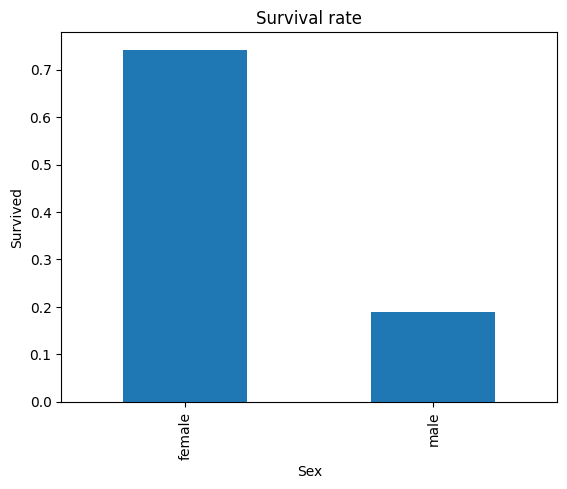

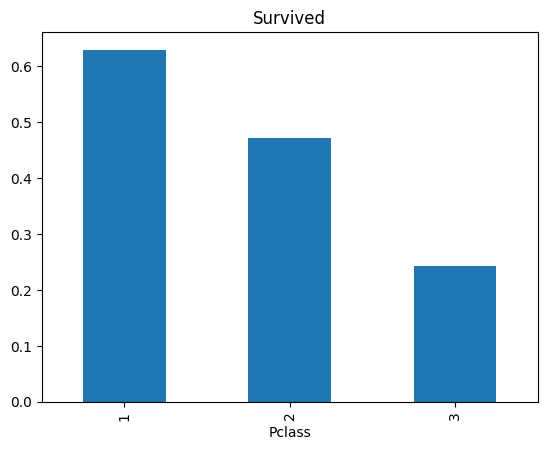

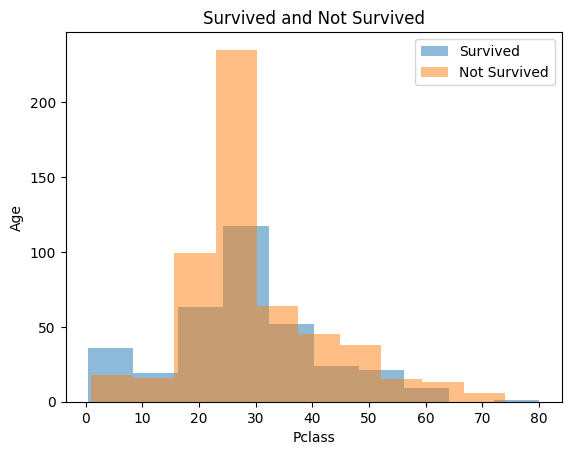

Pclass     -0.338481
Age        -0.064910
SibSp      -0.035322
Parch       0.081629
Fare        0.257307
Survived    1.000000
Name: Survived, dtype: float64
Accuracy: 75.42%


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score



url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

df.isnull().sum()

df["Age"] = df["Age"].fillna(df["Age"].median())
df = df.drop(columns=["Cabin"])
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

df.isnull().sum()

df.groupby("Sex")["Survived"].mean()

df.groupby("Pclass")["Survived"].mean()

df.groupby("Survived")["Age"].mean()

df.groupby("Sex")["Survived"].mean().plot(kind="bar")
plt.title("Survival rate")
plt.xlabel("Sex")
plt.ylabel("Survived")
plt.show()

df.groupby("Pclass")["Survived"].mean().plot(kind="bar")
plt.title("Survived")
plt.xlabel("Pclass")
plt.show()

df[df["Survived"]==1]["Age"].plot(kind="hist", alpha=0.5, label="Survived")
df[df["Survived"]==0]["Age"].plot(kind="hist", alpha=0.5, label="Not Survived")
plt.legend()
plt.title("Survived and Not Survived")
plt.ylabel("Age")
plt.xlabel("Pclass")
plt.show()

df_numeric = df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]]
correlation = df_numeric.corr()
print(correlation["Survived"].sort_values())

df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
X = df[["Pclass", "Age", "Fare", "SibSp", "Parch", "Sex"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = (model.predict(X_test))
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy: {accuracy:.2%}")




## Conclusions
1. Women survived at 3.9x the rate of men 74% vs 19%
2. First class passengers survived at 2.6x the rate of
   third class 63% vs 24%
3. Wealth Fare correlation: 0.26 was a stronger predictor
   than age correlation: -0.06
4. ML model achieved 75.42% accuracy using these insights

## Machine Learning Results
Decision Tree model achieved 75.42% accuracy predicting
survival — significantly better than random guessing 50%.
Key predictive features: Sex, Pclass, and Fare — all
confirming our EDA findings that gender and wealth were
the primary survival factors.

## Correlation Analysis
Passenger class -0.34 and fare paid 0.26
show the
strongest correlation with survival — both wealth indicators.
Age and family size show minimal correlation, confirming
wealth and gender were the primary survival factors.

## Age Distribution
No passengers over 80 survived. However, the age distributions
of survivors and non-survivors overlap significantly between
ages 20-40, confirming that age alone was not a strong
predictor of survival compared to gender and class.

## Wealth and Survival
First class passengers survived at nearly 3x the rate of
third class passengers 63% vs 24%, suggesting that
socioeconomic status played a significant role in survival.

## Age and Survival
Survivors were slightly younger on average (28 vs 30 years),
but the difference is small — suggesting age alone was less
important than gender or passenger class in determining survival.
